# RRG (k=4): Simulation vs AME with Resetting

This notebook computes ensemble-averaged time evolution on a random regular graph (RRG) with degree $k=4$ and compares:
- Monte Carlo simulation
- integrated AME differential equations

Current setup uses **resetting** ($r>0$).

To avoid clutter, the comparison focuses on **two selected** $s_{4,m}(t)$ components.

In [59]:
using Graphs
using Random
using Statistics
using Printf
using Plots

project_root = isdir(joinpath(pwd(), "src")) ? pwd() : dirname(dirname(pwd()))

# Always reload local module so new API changes are available in this kernel.
include(joinpath(project_root, "src", "VoterResetting.jl"))

Main.VoterResetting

In [64]:
# Simulation parameters (with resetting)
N = 1000
k = 4
m0 = 0
r = 0.5
nsamples = 5000
times = collect(range(0.0, 75, length=101))
seed = 1234

# Keep only two s_{k,m} components for clearer plots
selected_s_m = [0, 4]

# Use the SAME reset protocol in simulation and AME
delta_reset_protocol = VoterResetting.delta_reset(m0)

Random.seed!(seed)
G = random_regular_graph(N, k)
params = VoterResetting.ComplexParams(r, m0)

println("RRG ready (RESETTING): N=$N, k=$k, r=$r, m0=$m0, nsamples=$nsamples, ntimes=$(length(times)), selected_s_m=$(selected_s_m), reset=delta_reset($m0)")

RRG ready (RESETTING): N=1000, k=4, r=0.5, m0=0, nsamples=5000, ntimes=101, selected_s_m=[0, 4], reset=delta_reset(0)


In [ ]:
result = VoterResetting.simulate_degree_evolution_complex(
    G,
    params;
    reset=delta_reset_protocol,
    times=times,
    nsamples=nsamples,
    mode=:all,
)

@assert k in result.k_values "Requested k is not present in graph degree classes"
k_idx = findfirst(==(k), result.k_values)

s4 = result.s_values[k_idx]  # size: (ntimes, k+1), columns m=0..k
i4 = result.i_values[k_idx]  # size: (ntimes, k+1), columns m=0..k

sum_s = vec(sum(s4, dims=2))
sum_i = vec(sum(i4, dims=2))
sum_si = sum_s + sum_i
m_from_si = vec(sum(i4 .- s4, dims=2))

@printf("Max |sum(s+i)-1| over time: %.3e\n", maximum(abs.(sum_si .- 1.0)))

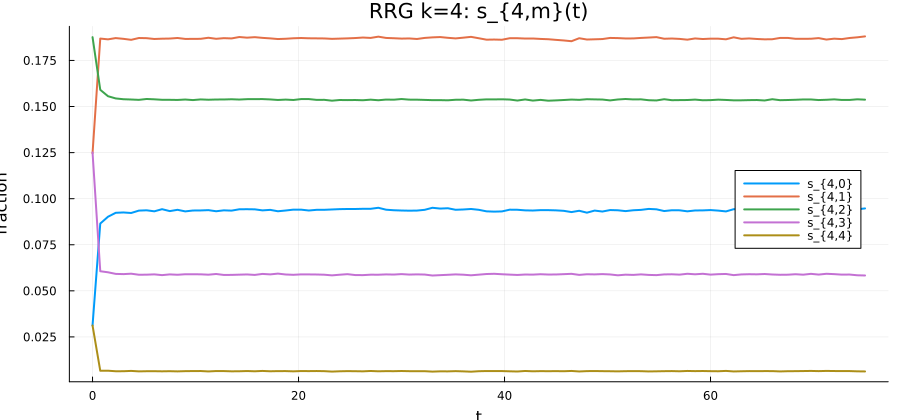

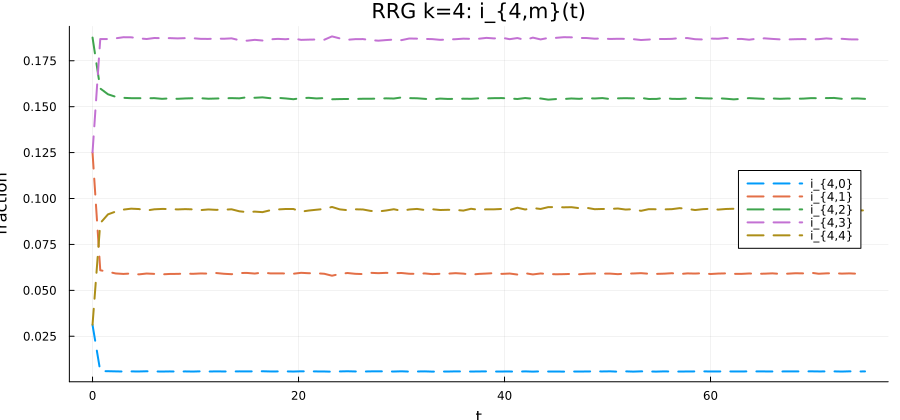

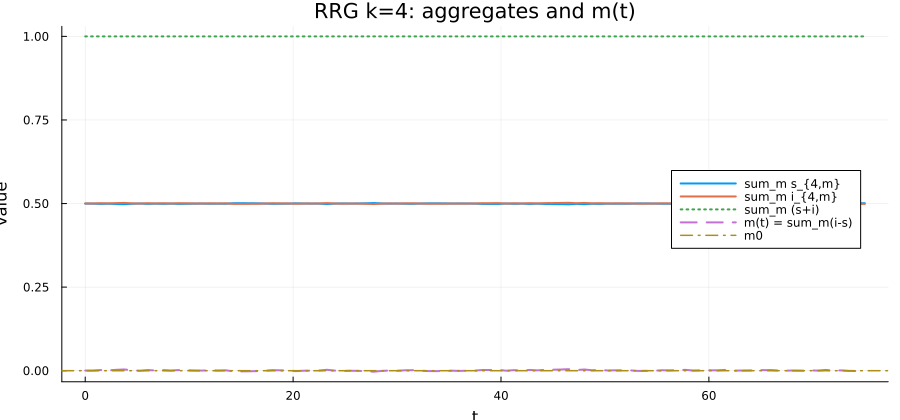

In [62]:
# Plot all s_{4,m}(t)
p_s = plot(size=(900, 420), legend=:right, xlabel="t", ylabel="fraction", title="RRG k=4: s_{4,m}(t)")
for m in 0:k
    plot!(p_s, result.times, s4[:, m + 1], lw=2, label="s_{$k,$m}")
end
display(p_s)

# Plot all i_{4,m}(t)
p_i = plot(size=(900, 420), legend=:right, xlabel="t", ylabel="fraction", title="RRG k=4: i_{4,m}(t)")
for m in 0:k
    plot!(p_i, result.times, i4[:, m + 1], lw=2, ls=:dash, label="i_{$k,$m}")
end
display(p_i)

# Aggregate checks and reconstructed magnetization
p_agg = plot(size=(900, 420), legend=:right, xlabel="t", ylabel="value", title="RRG k=4: aggregates and m(t)")
plot!(p_agg, result.times, sum_s, lw=2, label="sum_m s_{$k,m}")
plot!(p_agg, result.times, sum_i, lw=2, label="sum_m i_{$k,m}")
plot!(p_agg, result.times, sum_si, lw=2, ls=:dot, label="sum_m (s+i)")
plot!(p_agg, result.times, m_from_si, lw=2, ls=:dash, label="m(t) = sum_m(i-s)")
hline!(p_agg, [m0], ls=:dashdot, lw=1.5, label="m0")
display(p_agg)

In [ ]:
# Compare Monte Carlo simulation vs integrated AME equations on the same RRG case
ame = VoterResetting.solve_ame_evolution(
    G,
    m0,
    r,
    times;
    initial_condition=:m,
    reset=delta_reset_protocol,
)

@assert k in ame.k_values "Requested k is not present in AME degree classes"
k_idx_ame = findfirst(==(k), ame.k_values)

s4_ame = ame.s_values[k_idx_ame]  # (ntimes, k+1)
i4_ame = ame.i_values[k_idx_ame]  # (ntimes, k+1)

sum_s_ame = vec(sum(s4_ame, dims=2))
sum_i_ame = vec(sum(i4_ame, dims=2))
sum_si_ame = sum_s_ame + sum_i_ame
m_from_si_ame = vec(sum(i4_ame .- s4_ame, dims=2))

println("Comparison diagnostics (max abs diff over time):")
for m in selected_s_m
    ds = maximum(abs.(s4[:, m + 1] .- s4_ame[:, m + 1]))
    @printf("  m=%d  max|Δs|=%.3e\n", m, ds)
end
@printf("  max|Δ(sum_s)|=%.3e\n", maximum(abs.(sum_s .- sum_s_ame)))
@printf("  max|Δ(sum_i)|=%.3e\n", maximum(abs.(sum_i .- sum_i_ame)))
@printf("  max|Δ(m)|    =%.3e\n", maximum(abs.(m_from_si .- m_from_si_ame)))

# Only two selected s_{k,m}(t): simulation (solid) vs AME (dashed)
p_s_cmp = plot(size=(950, 450), legend=:right, xlabel="t", ylabel="fraction",
    title="RRG k=4 (r=$r, delta reset): selected s_{4,m}(t) — simulation vs AME")
for m in selected_s_m
    plot!(p_s_cmp, result.times, s4[:, m + 1], lw=2.5, label="sim s_{$k,$m}")
    plot!(p_s_cmp, ame.times, s4_ame[:, m + 1], lw=2.5, ls=:dash, label="AME s_{$k,$m}")
end
display(p_s_cmp)

# Aggregate comparison
p_agg_cmp = plot(size=(950, 450), legend=:right, xlabel="t", ylabel="value",
    title="RRG k=4 (r=$r, delta reset): aggregates — simulation vs AME")
plot!(p_agg_cmp, result.times, sum_s, lw=2, label="sim sum_m s")
plot!(p_agg_cmp, ame.times, sum_s_ame, lw=2, ls=:dash, label="AME sum_m s")
plot!(p_agg_cmp, result.times, sum_i, lw=2, label="sim sum_m i")
plot!(p_agg_cmp, ame.times, sum_i_ame, lw=2, ls=:dash, label="AME sum_m i")
plot!(p_agg_cmp, result.times, m_from_si, lw=2, color=:black, label="sim m(t)")
plot!(p_agg_cmp, ame.times, m_from_si_ame, lw=2, ls=:dash, color=:black, label="AME m(t)")
plot!(p_agg_cmp, result.times, sum_si, lw=2, ls=:dot, color=:gray, label="sim sum_m(s+i)")
plot!(p_agg_cmp, ame.times, sum_si_ame, lw=2, ls=:dashdot, color=:gray, label="AME sum_m(s+i)")
hline!(p_agg_cmp, [m0], ls=:dashdot, lw=1.5, color=:red, label="m0")
display(p_agg_cmp)